# Exercise 2b: Labor Income Share — Belgium and Poland
### Macroeconomics III, University of Copenhagen

## Step 1: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

## Step 2: Load the Data

In [2]:
df = pd.read_csv('national_accounts.csv')

## Step 3: Filter for Belgium, Poland, and Total Economy


In [3]:
# Filter for Belgium and Poland, total economy only
df_filtered = df[
    (df['geo_code'].isin(['BE', 'PL'])) &
    (df['nace_r2_code'] == 'TOT')
].copy()

print('Filtered data shape:', df_filtered.shape)
df_filtered[['geo_code', 'geo_name', 'year', 'COMP', 'VA_CP']].head(10)

Filtered data shape: (54, 23)


,geo_code,geo_name,year,COMP,VA_CP
57982,BE,Belgium,2021,244418.6,453019.9
57988,PL,Poland,2021,1031331.0,2320410.0
58014,BE,Belgium,2002,141984.8,244560.7
58072,BE,Belgium,2003,144668.6,251865.8
58130,BE,Belgium,2004,148850.7,264845.4
58182,PL,Poland,1995,137567.0,305683.0
58188,BE,Belgium,2005,153985.3,276828.7
58222,PL,Poland,2002,325632.0,719112.0
58240,PL,Poland,1996,177593.0,381615.0
58246,BE,Belgium,2006,161393.2,290022.6


## Step 4: Compute Labor Income Share

$$\text{Labor share}_t = \frac{\text{COMP}_t}{\text{VA\_CP}_t}$$

- **COMP**: total employee compensation (wages, bonuses, etc.)
- **VA_CP**: gross value added at current prices

In [4]:
df_filtered['labor_share'] = df_filtered['COMP'] / df_filtered['VA_CP']

df_filtered[['geo_name', 'year', 'COMP', 'VA_CP', 'labor_share']].head(10)

,geo_name,year,COMP,VA_CP,labor_share
57982,Belgium,2021,244418.6,453019.9,0.539532
57988,Poland,2021,1031331.0,2320410.0,0.444461
58014,Belgium,2002,141984.8,244560.7,0.580571
58072,Belgium,2003,144668.6,251865.8,0.574388
58130,Belgium,2004,148850.7,264845.4,0.562029
58182,Poland,1995,137567.0,305683.0,0.450032
58188,Belgium,2005,153985.3,276828.7,0.556248
58222,Poland,2002,325632.0,719112.0,0.452825
58240,Poland,1996,177593.0,381615.0,0.465372
58246,Belgium,2006,161393.2,290022.6,0.556485


## Step 5: Plot Labor Income Share Over Time

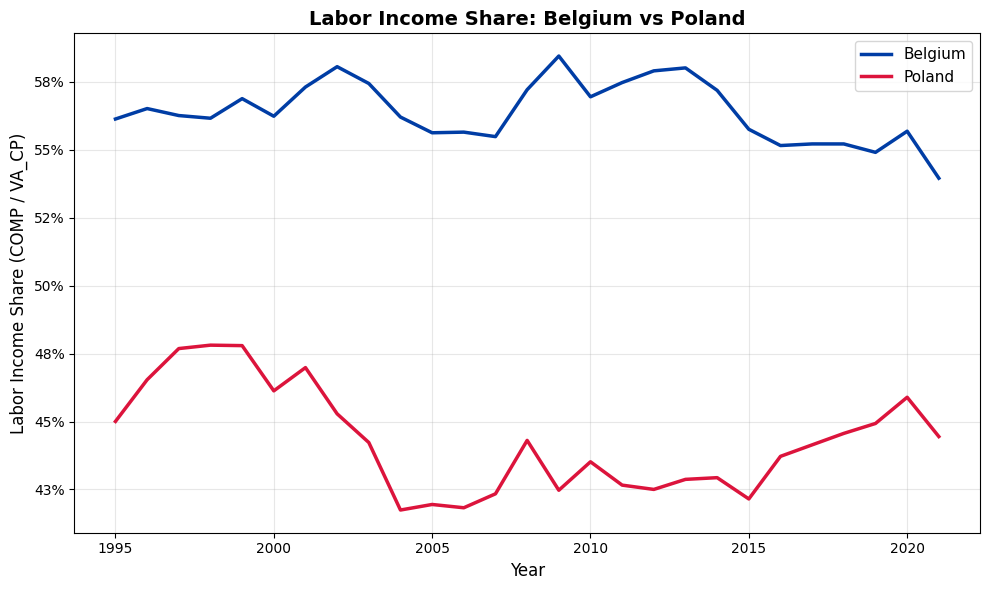

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

colors  = {'BE': '#003DA5', 'PL': '#DC143C'}
labels  = {'BE': 'Belgium', 'PL': 'Poland'}

for code in ['BE', 'PL']:
    data = df_filtered[df_filtered['geo_code'] == code].sort_values('year')
    ax.plot(
        data['year'],
        data['labor_share'],
        color=colors[code],
        linewidth=2.5,
        label=labels[code]
    )

ax.set_title('Labor Income Share: Belgium vs Poland', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Labor Income Share (COMP / VA_CP)', fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('labor_income_share.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6: Average Labor Income Share and Implied Alpha

From the model we showed that the labor income share equals $1 - \alpha$:

$$\frac{w_t L_t}{Y_t} = 1 - \alpha \implies \alpha = 1 - \text{labor share}$$

So the average labor share directly pins down $\alpha$, the capital share parameter.

In [6]:
for code in ['BE', 'PL']:
    data = df_filtered[df_filtered['geo_code'] == code]
    avg_share = data['labor_share'].mean()
    alpha     = 1 - avg_share
    print(f'\n{labels[code]}:')
    print(f'  Average labor income share : {avg_share:.3f}  ({avg_share*100:.1f}%)')
    print(f'  Implied alpha (1 - share)  : {alpha:.3f}')


Belgium:
  Average labor income share : 0.564  (56.4%)
  Implied alpha (1 - share)  : 0.436

Poland:
  Average labor income share : 0.443  (44.3%)
  Implied alpha (1 - share)  : 0.557


---
# Exercise 2c: Capital-Output Ratio — Belgium and Poland

The capital-output ratio is defined as:

$$\frac{K_t}{Y_t} = \frac{\text{Kq\_GFCF}_t}{\text{VA\_Q}_t}$$

- **Kq_GFCF**: net capital stock in chain-linked volumes (from capital accounts)
- **VA_Q**: gross value added in chain-linked volumes (from national accounts)


## Step 1: Load Capital Accounts and Merge with National Accounts

In [7]:
# Load capital accounts
cap = pd.read_csv('capital accounts.csv')

# Filter for Belgium and Poland, total economy
cap_filtered = cap[
    (cap['geo_code'].isin(['BE', 'PL'])) &
    (cap['nace_r2_code'] == 'TOT')
][['geo_code', 'year', 'Kq_GFCF']].copy()

# Pull VA_Q from national accounts (df already loaded above)
va_filtered = df[
    (df['geo_code'].isin(['BE', 'PL'])) &
    (df['nace_r2_code'] == 'TOT')
][['geo_code', 'year', 'VA_Q']].copy()

# Merge on country and year
df_ky = pd.merge(cap_filtered, va_filtered, on=['geo_code', 'year'])

print('Merged data shape:', df_ky.shape)
df_ky.head(10)


Merged data shape: (54, 4)


,geo_code,year,Kq_GFCF,VA_Q
0,BE,2021,1.517558e+06,4.403617e+05
1,PL,2021,3.364586e+06,2.223039e+06
2,BE,2002,1.127942e+06,3.287285e+05
3,BE,2003,1.141503e+06,3.323909e+05
4,BE,2004,1.150499e+06,3.429341e+05
5,PL,1995,NaN,8.257104e+05
6,BE,2005,1.183344e+06,3.513220e+05
7,PL,2002,1.837946e+06,1.082718e+06
8,PL,1996,NaN,8.715146e+05
9,BE,2006,1.204763e+06,3.599303e+05


## Step 2: Compute the Capital-Output Ratio

In [8]:
df_ky['KY_ratio'] = df_ky['Kq_GFCF'] / df_ky['VA_Q']

df_ky[['geo_code', 'year', 'Kq_GFCF', 'VA_Q', 'KY_ratio']].sort_values(['geo_code', 'year']).head(14)


,geo_code,year,Kq_GFCF,VA_Q,KY_ratio
30,BE,1995,9.811426e+05,279372.037517,3.511957
33,BE,1996,1.000092e+06,281931.539330,3.547286
36,BE,1997,1.021943e+06,292213.260549,3.497252
42,BE,1998,1.043331e+06,297670.638621,3.504984
46,BE,1999,1.065556e+06,307572.996736,3.464400
51,BE,2000,1.089387e+06,318602.978973,3.419261
53,BE,2001,1.111821e+06,323446.835337,3.437416
2,BE,2002,1.127942e+06,328728.485443,3.431228
3,BE,2003,1.141503e+06,332390.865566,3.434220
4,BE,2004,1.150499e+06,342934.107499,3.354870


## Step 3: Plot Capital-Output Ratio Over Time

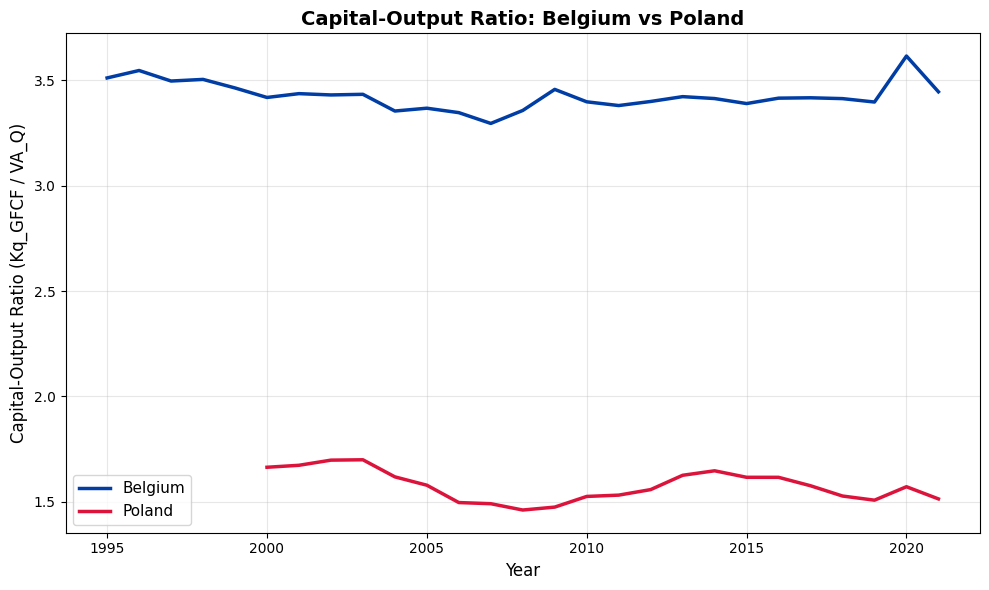

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'BE': '#003DA5', 'PL': '#DC143C'}
labels = {'BE': 'Belgium', 'PL': 'Poland'}

for code in ['BE', 'PL']:
    data = df_ky[df_ky['geo_code'] == code].sort_values('year').dropna(subset=['KY_ratio'])
    ax.plot(
        data['year'],
        data['KY_ratio'],
        color=colors[code],
        linewidth=2.5,
        label=labels[code]
    )

ax.set_title('Capital-Output Ratio: Belgium vs Poland', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Capital-Output Ratio (Kq_GFCF / VA_Q)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('capital_output_ratio.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 4: Average Capital-Output Ratio

In [10]:
for code in ['BE', 'PL']:
    data = df_ky[df_ky['geo_code'] == code].dropna(subset=['KY_ratio'])
    avg_ky = data['KY_ratio'].mean()
    print(f'{labels[code]}:')
    print(f'  Average capital-output ratio (K/Y) : {avg_ky:.3f}')
    print(f'  Years covered                       : {int(data["year"].min())}–{int(data["year"].max())}')
    print()


Belgium:
  Average capital-output ratio (K/Y) : 3.428
  Years covered                       : 1995–2021

Poland:
  Average capital-output ratio (K/Y) : 1.576
  Years covered                       : 2000–2021

